# Value Estimator Variance Analysis

This notebook analyzes the variance of different value estimation methods compared to Monte Carlo.

For each state and method, we:
1. Compute mean and variance of predictions across different training batches
2. Calculate variance ratio: Var(method) / Var(MC)
3. Plot histogram of variance ratios

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Predictions Data

In [4]:
# Configure experiment to analyze
EXPERIMENT_ID = "cartpole_test"  # Change this to your experiment ID
EXPERIMENT_DIR = Path(f"experiments/{EXPERIMENT_ID}")
RESULTS_DIR = EXPERIMENT_DIR / "results"

# Load predictions
predictions_file = RESULTS_DIR / "predictions.csv"
if predictions_file.exists():
    df = pd.read_csv(predictions_file)
    print(f"Loaded {len(df)} predictions")
    print(f"\nDataset shape:")
    print(f"  States: {df['state_idx'].nunique()}")
    print(f"  Methods: {df['method'].nunique()}")
    print(f"  Batches: {df['batch_idx'].nunique()}")
    print(f"\nMethods: {sorted(df['method'].unique())}")
    print(f"\nFirst few rows:")
    display(df.head(10))
else:
    print(f"ERROR: Predictions file not found at {predictions_file}")
    print("Please run: python -m src.evaluate --config <your_config>.yaml")

Loaded 3287580 predictions

Dataset shape:
  States: 164379
  Methods: 2
  Batches: 10

Methods: ['dqn', 'monte_carlo']

First few rows:


,state_idx,method,batch_idx,predicted_value
0,0,monte_carlo,0,75.549350
1,1,monte_carlo,0,74.433240
2,2,monte_carlo,0,75.302410
3,3,monte_carlo,0,74.156624
4,4,monte_carlo,0,75.014270
5,5,monte_carlo,0,73.677920
6,6,monte_carlo,0,74.568090
7,7,monte_carlo,0,75.668360
8,8,monte_carlo,0,74.677300
9,9,monte_carlo,0,73.204000


## 2. Compute Mean and Variance per State

In [5]:
# Group by state and method, compute statistics across batches
stats = df.groupby(['state_idx', 'method'])['predicted_value'].agg(
    mean='mean',
    variance='var',
    std='std',
    count='count'
).reset_index()

print(f"Computed statistics for {len(stats)} (state, method) pairs")
print(f"\nExample statistics:")
display(stats.head(10))

# Check for missing data
print(f"\nMissing values:")
print(stats.isnull().sum())

Computed statistics for 328758 (state, method) pairs

Example statistics:


,state_idx,method,mean,variance,std,count
0,0,dqn,4.709097,2.926131,1.710594,10
1,0,monte_carlo,75.867100,0.922358,0.960395,10
2,1,dqn,4.722010,2.866561,1.693092,10
3,1,monte_carlo,74.877686,1.121472,1.058996,10
4,2,dqn,4.707570,2.925461,1.710398,10
5,2,monte_carlo,75.570881,0.900917,0.949167,10
6,3,dqn,4.720722,2.862364,1.691852,10
7,3,monte_carlo,74.449652,1.129205,1.062640,10
8,4,dqn,4.705811,2.923583,1.709849,10
9,4,monte_carlo,75.215178,0.887573,0.942111,10



Missing values:
state_idx    0
method       0
mean         0
variance     0
std          0
count        0
dtype: int64


## 3. Compute Variance Ratios Against Monte Carlo

In [6]:
# Extract Monte Carlo variances
mc_variances = stats[stats['method'] == 'monte_carlo'][['state_idx', 'variance']].copy()
mc_variances.columns = ['state_idx', 'mc_variance']

print(f"Monte Carlo variance statistics:")
print(mc_variances['mc_variance'].describe())

# Merge MC variances with all methods
stats_with_mc = stats.merge(mc_variances, on='state_idx', how='left')

# Compute variance ratio
stats_with_mc['variance_ratio'] = stats_with_mc['variance'] / stats_with_mc['mc_variance']

# Filter out Monte Carlo itself
variance_ratios = stats_with_mc[stats_with_mc['method'] != 'monte_carlo'].copy()

print(f"\nVariance ratios computed for {len(variance_ratios)} (state, method) pairs")
print(f"\nVariance ratio statistics by method:")
display(variance_ratios.groupby('method')['variance_ratio'].describe())

Monte Carlo variance statistics:
count    164379.000000
mean          5.034374
std           7.763415
min           0.082231
25%           1.547292
50%           2.700945
75%           5.201924
max         170.964940
Name: mc_variance, dtype: float64

Variance ratios computed for 164379 (state, method) pairs

Variance ratio statistics by method:


,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
dqn,164379.0,1.38528,1.26771,0.00109,0.533641,1.049777,1.857215,43.115408


## 4. Handle Edge Cases

In [7]:
# Check for problematic values
print("Edge case analysis:")
print(f"  States with MC variance = 0: {(mc_variances['mc_variance'] == 0).sum()}")
print(f"  Infinite variance ratios: {np.isinf(variance_ratios['variance_ratio']).sum()}")
print(f"  NaN variance ratios: {variance_ratios['variance_ratio'].isna().sum()}")

# Filter out problematic ratios for visualization
variance_ratios_clean = variance_ratios[
    np.isfinite(variance_ratios['variance_ratio']) & 
    (variance_ratios['mc_variance'] > 1e-10)  # Filter out near-zero MC variance
].copy()

print(f"\nClean variance ratios: {len(variance_ratios_clean)} / {len(variance_ratios)}")

Edge case analysis:
  States with MC variance = 0: 0
  Infinite variance ratios: 0
  NaN variance ratios: 0

Clean variance ratios: 164379 / 164379


## 5. Plot Variance Ratio Histograms

Plotting histograms for 1 methods: ['dqn']

Saved plot to experiments/cartpole_test/results/variance_ratio_histograms.png


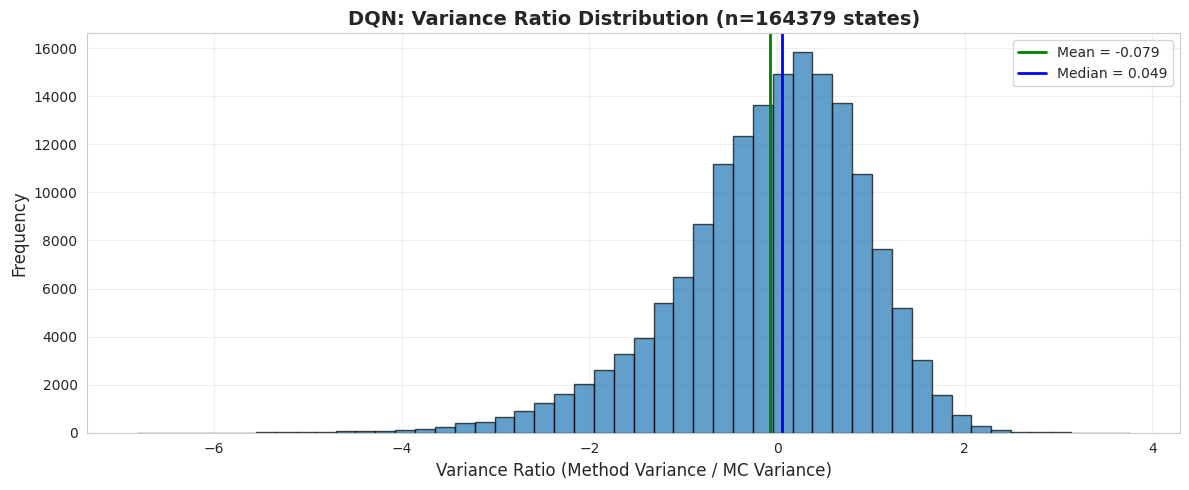

In [10]:
# Get unique methods (excluding MC)
methods = sorted(variance_ratios_clean['method'].unique())
n_methods = len(methods)

print(f"Plotting histograms for {n_methods} methods: {methods}")

# Create subplots
fig, axes = plt.subplots(n_methods, 1, figsize=(12, 5 * n_methods))
if n_methods == 1:
    axes = [axes]

for idx, method in enumerate(methods):
    ax = axes[idx]
    method_data = np.log(variance_ratios_clean[variance_ratios_clean['method'] == method]['variance_ratio'])
    
    # Plot histogram
    ax.hist(method_data, bins=50, alpha=0.7, edgecolor='black')
    
    
    # Add statistics
    mean_ratio = method_data.mean()
    median_ratio = method_data.median()
    ax.axvline(mean_ratio, color='green', linestyle='-', linewidth=2, label=f'Mean = {mean_ratio:.3f}')
    ax.axvline(median_ratio, color='blue', linestyle='-', linewidth=2, label=f'Median = {median_ratio:.3f}')
    
    # Labels and title
    ax.set_xlabel('Variance Ratio (Method Variance / MC Variance)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{method.upper()}: Variance Ratio Distribution (n={len(method_data)} states)', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'variance_ratio_histograms.png', dpi=300, bbox_inches='tight')
print(f"\nSaved plot to {RESULTS_DIR / 'variance_ratio_histograms.png'}")
plt.show()

## 6. Combined Comparison Plot

In [ ]:
# Overlaid histograms for comparison
fig, ax = plt.subplots(figsize=(14, 7))

for method in methods:
    method_data = variance_ratios_clean[variance_ratios_clean['method'] == method]['variance_ratio']
    ax.hist(method_data, bins=50, alpha=0.5, label=f'{method} (mean={method_data.mean():.3f})', edgecolor='black')

ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1 (Equal to MC)')
ax.set_xlabel('Variance Ratio (Method Variance / MC Variance)', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Variance Ratio Distribution: All Methods vs Monte Carlo', fontsize=16, fontweight='bold')
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'variance_ratio_comparison.png', dpi=300, bbox_inches='tight')
print(f"Saved plot to {RESULTS_DIR / 'variance_ratio_comparison.png'}")
plt.show()

## 7. Summary Statistics Table

In [ ]:
# Create comprehensive summary table
summary = variance_ratios_clean.groupby('method')['variance_ratio'].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max',
    ('q25', lambda x: x.quantile(0.25)),
    ('q75', lambda x: x.quantile(0.75)),
    ('pct_lower_var', lambda x: (x < 1.0).sum() / len(x) * 100),  # % with lower variance than MC
]).round(4)

summary.columns = ['N States', 'Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Q25', 'Q75', '% Lower Var than MC']

print("\n" + "="*80)
print("VARIANCE RATIO SUMMARY: Method Variance / Monte Carlo Variance")
print("="*80)
print("\nInterpretation:")
print("  - Ratio < 1: Method has LOWER variance than Monte Carlo (more stable)")
print("  - Ratio = 1: Method has EQUAL variance to Monte Carlo")
print("  - Ratio > 1: Method has HIGHER variance than Monte Carlo (less stable)")
print("\n")
display(summary)

# Save to CSV
summary.to_csv(RESULTS_DIR / 'variance_ratio_summary.csv')
print(f"\nSaved summary to {RESULTS_DIR / 'variance_ratio_summary.csv'}")

## 8. Example: Inspect Specific States

In [ ]:
# Inspect states with highest/lowest variance ratios
example_method = methods[0] if methods else None

if example_method:
    method_ratios = variance_ratios_clean[variance_ratios_clean['method'] == example_method].copy()
    method_ratios = method_ratios.sort_values('variance_ratio')
    
    print(f"\n{example_method.upper()}: States with LOWEST variance ratios (most stable):")
    display(method_ratios.head(10)[['state_idx', 'mean', 'variance', 'mc_variance', 'variance_ratio']])
    
    print(f"\n{example_method.upper()}: States with HIGHEST variance ratios (least stable):")
    display(method_ratios.tail(10)[['state_idx', 'mean', 'variance', 'mc_variance', 'variance_ratio']])

## 9. Box Plot Comparison

In [ ]:
# Box plot for clearer comparison
fig, ax = plt.subplots(figsize=(10, 6))

variance_ratios_clean.boxplot(column='variance_ratio', by='method', ax=ax)
ax.axhline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1')
ax.set_xlabel('Method', fontsize=12)
ax.set_ylabel('Variance Ratio (Method / MC)', fontsize=12)
ax.set_title('Variance Ratio Distribution by Method', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove default title
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'variance_ratio_boxplot.png', dpi=300, bbox_inches='tight')
print(f"Saved plot to {RESULTS_DIR / 'variance_ratio_boxplot.png'}")
plt.show()